# 03 · Context-Aware Alerting & Root Cause Analysis (RCA)

*Code execution step below.*

## 0 · Imports & Environment

In [1]:
import utils.plot_csv_exporter
import sys, os, json, uuid, logging, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib, matplotlib.pyplot as plt, matplotlib.patches as mpatches
from IPython.display import display, HTML, JSON

# Project path.
notebook_dir = Path(os.getcwd()).resolve()
for candidate in [notebook_dir, notebook_dir.parent]:
    target = candidate / 'alibaba_trace'
    if (target / 'incident_response.py').exists():
        if str(target) not in sys.path: sys.path.insert(0, str(target))
        ALIBABA_DIR = target
        break
else:
    ALIBABA_DIR = notebook_dir

# Project modules.
from model_architecture import build_model, load_model
from data_pipeline import FEATURE_COLS, META_COLS, WINDOW_SIZE
from incident_response import (
    ContainerContext, SeverityScorer, ContextAwareRCA,
    AlertGenerator, IncidentPipeline, CONTAINER_PROFILES, FEATURE_META,
)

logging.basicConfig(level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(name)s — %(message)s')
print(f'PyTorch  : {torch.__version__}')
print(f'NumPy    : {np.__version__}')
print(f'Pandas   : {pd.__version__}')
print(f'Device   : {"cuda" if torch.cuda.is_available() else "cpu"}')
print(f'Features : {FEATURE_COLS}')
print('All imports OK.')


Hooked matplotlib.savefig to automatically export plot CSVs.
PyTorch  : 2.11.0+cpu
NumPy    : 2.4.2
Pandas   : 3.0.1
Device   : cpu
Features : ['cpu_util_percent', 'mem_util_percent', 'cpu_request', 'mem_request', 'net_in', 'net_out', 'disk_io_percent']
All imports OK.


## 1 · Configuration

In [2]:
OUTPUTS_DIR  = ALIBABA_DIR / 'outputs'
MODEL_PATH   = OUTPUTS_DIR / 'model.pt'
FIGURES_DIR  = OUTPUTS_DIR / 'thesis_figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

WINDOW      = int(WINDOW_SIZE)   # 50
N_TS_FEAT   = len(FEATURE_COLS)  # 7
N_META_FEAT = len(META_COLS)     # 2
LATENT_DIM  = 64
LSTM_UNITS  = (128, 64)
DROPOUT     = 0.2
RANDOM_SEED = 42
N_CALIB     = 5_000

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Configuration OK')
print(f'  Window  : {WINDOW} timesteps x {N_TS_FEAT} features')
print(f'  FiLM    : {N_META_FEAT}-dimensional meta vector')
print(f'  Figures : {FIGURES_DIR}')


Configuration OK
  Window  : 50 timesteps x 7 features
  FiLM    : 2-dimensional meta vector
  Figures : C:\Users\kaspe\Desktop\Project\project\alibaba_trace\outputs\thesis_figures


## 2 · Load BiLSTM-FiLM Model

*Code execution step below.*

In [3]:
if MODEL_PATH.exists():
    autoencoder = load_model(
        checkpoint_path=str(MODEL_PATH), window_size=WINDOW,
        n_ts_features=N_TS_FEAT, n_meta_features=N_META_FEAT,
        latent_dim=LATENT_DIM, lstm_units=LSTM_UNITS,
        dropout_rate=DROPOUT, device=DEVICE,
    )
    MODEL_AVAILABLE = True
    print(f'Trained model loaded: {MODEL_PATH}')
else:
    autoencoder = build_model(
        window_size=WINDOW, n_ts_features=N_TS_FEAT,
        n_meta_features=N_META_FEAT, latent_dim=LATENT_DIM,
        lstm_units=LSTM_UNITS, dropout_rate=DROPOUT, device=DEVICE,
    )
    autoencoder.eval()
    MODEL_AVAILABLE = False
    print('DEMO mode — no checkpoint found; reconstruction errors will be')
    print('scaled to produce representative Severity tiers.')

n_p = sum(p.numel() for p in autoencoder.parameters())
print(f'  Architecture : BiLSTM-FiLM Autoencoder')
print(f'  Parameters   : {n_p:,}')
print(f'  Device       : {DEVICE}')


2026-04-18 21:18:37,786  [INFO]  model_architecture – Built BiLSTMFiLMAutoencoder (single-head) | window=50 | ts_feat=7 | meta_feat=2 | latent=64 | params=696,327


DEMO mode — no checkpoint found; reconstruction errors will be
scaled to produce representative Severity tiers.
  Architecture : BiLSTM-FiLM Autoencoder
  Parameters   : 696,327
  Device       : cpu


## 3 · Initialise Incident Response Engine

*Code execution step below.*

In [4]:
# Calibration on N_CALIB synthetic normal windows.
rng = np.random.default_rng(RANDOM_SEED)
normal_base  = rng.uniform(0.2, 0.8, (N_CALIB, WINDOW, N_TS_FEAT)).astype(np.float32)
meta_dummy   = torch.zeros(256, N_META_FEAT, device=DEVICE)
baseline_mse = []

autoencoder.eval()
with torch.no_grad():
    for s in range(0, N_CALIB, 256):
        e   = min(s + 256, N_CALIB)
        ts  = torch.from_numpy(normal_base[s:e]).to(DEVICE)
        m   = meta_dummy[:len(ts)]
        r   = autoencoder(ts, m)
        mse = ((ts - r) ** 2).mean(dim=(1, 2)).cpu().numpy()
        baseline_mse.append(mse)

baseline_mse = np.concatenate(baseline_mse).astype(np.float64)

scorer  = SeverityScorer().calibrate(baseline_mse)
rca     = ContextAwareRCA(feature_cols=FEATURE_COLS, secondary_threshold=0.60)
alerter = AlertGenerator(
    cluster='alibaba-k8s-production',
    namespace='workload',
    receiver='container-alerts-pagerduty',
)
pipeline = IncidentPipeline(scorer=scorer, rca=rca, alerter=alerter)

t = scorer.threshold_summary()
THRESHOLD_P95  = float(scorer.threshold_summary()['p95'])
print(f'Calibration complete ({N_CALIB:,} baseline windows)')
print(f'  Baseline MSE  mu={baseline_mse.mean():.6f}  sigma={baseline_mse.std():.6f}')
print(f'  P95  (Warning  threshold) : {t["p95"]:.6f}')
print(f'  P98  (High     threshold) : {t["p98"]:.6f}')
print(f'  P995 (Critical threshold) : {t["p99.5"]:.6f}')
print(f'\n{scorer!r}')
print(f'{alerter!r}')


2026-04-18 21:18:40,785  [INFO]  incident_response – SeverityScorer calibrated — P95=0.032489 | P98=0.033034 | P99.5=0.033787


Calibration complete (5,000 baseline windows)
  Baseline MSE  mu=0.030089  sigma=0.001437
  P95  (Warning  threshold) : 0.032489
  P98  (High     threshold) : 0.033034
  P995 (Critical threshold) : 0.033787

SeverityScorer(p95=0.032489, p98=0.033034, p99.5=0.033787)
AlertGenerator(cluster='alibaba-k8s-production', namespace='workload')


## 4 · Define 5 ContainerContext Scenarios

*Code execution step below.*

In [5]:
# ContainerContext: 5 different container types.
CONTEXTS = [
    ContainerContext.from_ids(
        container_id='api-gateway-7f3a',  machine_id='node-us-east-01',
        container_type='api',             tier='frontend',
        environment='production',         namespace='prod-api',
        pod_name='api-gateway-7f3a-k9rv2',
    ),
    ContainerContext.from_ids(
        container_id='db-postgres-5b',    machine_id='node-us-east-02',
        container_type='database',        tier='data',
        environment='production',         namespace='prod-data',
        pod_name='db-postgres-5b-xw42n',
    ),
    ContainerContext.from_ids(
        container_id='cache-redis-2c',    machine_id='node-us-east-01',
        container_type='cache',           tier='backend',
        environment='production',         namespace='prod-cache',
        pod_name='cache-redis-2c-p87jm',
    ),
    ContainerContext.from_ids(
        container_id='worker-kafka-1a',   machine_id='node-eu-west-03',
        container_type='worker',          tier='infrastructure',
        environment='production',         namespace='prod-jobs',
        pod_name='worker-kafka-1a-qt19s',
    ),
    ContainerContext.from_ids(
        container_id='ml-triton-9d',      machine_id='node-gpu-01',
        container_type='ml_inference',    tier='backend',
        environment='staging',            namespace='ml-staging',
        pod_name='ml-triton-9d-vn33p',
    ),
]

print('ContainerContext objects with FiLM metadata vectors:')
print('=' * 68)
for i, ctx in enumerate(CONTEXTS, 1):
    pm = ctx.profile_meta()
    print(f'{i}. {ctx.profile_icon()} [{ctx.container_type:>12}] {ctx.container_id:22s}'
          f'film_vec={ctx.film_vector_str()}')
    print(f'   Tier: {ctx.tier:14s} Env: {ctx.environment:12s} '
          f'Profile: {pm["display_name"]}')
    print()
print('=> Each container has a UNIQUE FiLM vector — the model conditioned')
print('   its reconstruction separately for each workload type.')


ContainerContext objects with FiLM metadata vectors:
1. ⚙️ [         api] api-gateway-7f3a      film_vec=[0.1499, 0.0941]
   Tier: frontend       Env: production   Profile: Generic Microservice

2. ⚙️ [    database] db-postgres-5b        film_vec=[0.0470, 0.2332]
   Tier: data           Env: production   Profile: Generic Microservice

3. ⚙️ [       cache] cache-redis-2c        film_vec=[0.7778, 0.0941]
   Tier: backend        Env: production   Profile: Generic Microservice

4. ⚙️ [      worker] worker-kafka-1a       film_vec=[0.0908, 0.4234]
   Tier: infrastructure Env: production   Profile: Generic Microservice

5. ⚙️ [ml_inference] ml-triton-9d          film_vec=[0.0710, 0.1768]
   Tier: backend        Env: staging      Profile: Generic Microservice

=> Each container has a UNIQUE FiLM vector — the model conditioned
   its reconstruction separately for each workload type.


## 5 · Simulate 5 Anomalous Time-Series Windows

*Code execution step below.*

In [6]:
def _base(rng_):
    """Smooth baseline window in [0.2, 0.7] — represents normal operation."""
    t = np.linspace(0, 2*np.pi, WINDOW)
    return np.clip(np.stack([
        0.45 + 0.10*np.sin(t)       + rng_.normal(0, 0.01, WINDOW),
        0.55 + 0.08*np.sin(t+1.0)   + rng_.normal(0, 0.01, WINDOW),
        0.40 + 0.05*np.cos(t)       + rng_.normal(0, 0.01, WINDOW),
        0.50 + 0.06*np.cos(t+0.5)   + rng_.normal(0, 0.01, WINDOW),
        0.30 + 0.07*np.abs(np.sin(t))+ rng_.normal(0, 0.01, WINDOW),
        0.28 + 0.05*np.abs(np.cos(t))+ rng_.normal(0, 0.01, WINDOW),
        0.25 + 0.06*np.sin(t+2.0)   + rng_.normal(0, 0.01, WINDOW),
    ], axis=1).astype(np.float32), 0.01, 0.99)

rng_s = np.random.default_rng(RANDOM_SEED + 7)

# 1. API Gateway - CPU spike (traffic surge, last 15 steps)
w1 = _base(rng_s);  w1[-15:, 0] = np.clip(0.93 + rng_s.normal(0, 0.02, 15), 0.88, 0.99)

# 2. PostgreSQL - Memory ramp (buffer pool exhaustion)
w2 = _base(rng_s);  w2[:, 1]    = np.clip(np.linspace(0.58, 0.97, WINDOW) + rng_s.normal(0,0.01,WINDOW), 0.01, 0.99)

# 3. Redis Cache - Network inbound flood (eviction storm from KEYS scan)
w3 = _base(rng_s);  w3[WINDOW//3:, 4] = np.clip(0.91 + rng_s.normal(0,0.03,WINDOW-WINDOW//3), 0.84, 0.99)

# 4. Kafka Worker - Disk I/O thrash (large batch writing to local disk)
t4 = np.linspace(0, 4*np.pi, WINDOW)
w4 = _base(rng_s);  w4[:, 6] = np.clip(0.87 + 0.09*np.sin(5*t4) + rng_s.normal(0,0.02,WINDOW), 0.74, 0.99)

# 5. ML Inference - Memory cascade + secondary CPU (model OOM)
w5 = _base(rng_s)
w5[WINDOW//4:, 1] = np.clip(0.90 + rng_s.normal(0,0.02,WINDOW-WINDOW//4), 0.83, 0.99)
w5[WINDOW//4:, 0] = np.clip(0.86 + rng_s.normal(0,0.03,WINDOW-WINDOW//4), 0.78, 0.99)

WINDOWS = [w1, w2, w3, w4, w5]

TIMESTAMPS = [
    '2026-04-15T18:00:05.123Z',
    '2026-04-15T18:00:17.456Z',
    '2026-04-15T18:00:29.789Z',
    '2026-04-15T18:00:41.012Z',
    '2026-04-15T18:00:53.345Z',
]

print('Anomalous windows constructed:')
for i, (ctx, w) in enumerate(zip(CONTEXTS, WINDOWS), 1):
    print(f'  Window {i}: {ctx.profile_icon()} {ctx.container_type:>12} {ctx.container_id:22s}'
          f'shape={w.shape}  range=[{w.min():.2f},{w.max():.2f}]')


Anomalous windows constructed:
  Window 1: ⚙️          api api-gateway-7f3a      shape=(50, 7)  range=[0.17,0.96]
  Window 2: ⚙️     database db-postgres-5b        shape=(50, 7)  range=[0.17,0.99]
  Window 3: ⚙️        cache cache-redis-2c        shape=(50, 7)  range=[0.18,0.96]
  Window 4: ⚙️       worker worker-kafka-1a       shape=(50, 7)  range=[0.26,0.99]
  Window 5: ⚙️ ml_inference ml-triton-9d          shape=(50, 7)  range=[0.18,0.96]


## 6 · Run Inference + Incident Response Pipeline

*Code execution step below.*

In [7]:
INCIDENT_EVENTS = []

# Severity-scaling multipliers for demo mode (untrained model)
# These ensure each scenario falls in a different severity tier for demonstration.
DEMO_MULTS = [8.5, 13.0, 7.0, 5.8, 16.0]

print('Running BiLSTM-FiLM inference + IncidentPipeline...')
print('=' * 72)

autoencoder.eval()
with torch.no_grad():
    for i, (ctx, win, ts_str) in enumerate(zip(CONTEXTS, WINDOWS, TIMESTAMPS)):

        # Forward pass through the model with this container's FiLM vector.
        ts_t    = torch.from_numpy(win[np.newaxis]).to(DEVICE)            # (1,W,F)
        meta_t  = torch.from_numpy(ctx.film_meta_vector[np.newaxis]).to(DEVICE)  # (1,M)
        recon_t = autoencoder(ts_t, meta_t)                               # (1,W,F)

        original_np = ts_t.squeeze(0).cpu().numpy()    # (W,F)
        recon_np    = recon_t.squeeze(0).cpu().numpy() # (W,F)

        mse = float(((original_np - recon_np) ** 2).mean())
        if not MODEL_AVAILABLE:
            mse = mse * DEMO_MULTS[i]   # Scale for demo severity diversity

        # Incident pipeline.
        event = pipeline.process(
            original=original_np, reconstructed=recon_np,
            mse_score=mse, context=ctx, timestamp_utc=ts_str,
        )
        INCIDENT_EVENTS.append(event)

        SEV_PAL = {'Critical':'\033[91m','High':'\033[93m',
                   'Warning':'\033[94m','Normal':'\033[92m'}
        R = '\033[0m'
        
        # Original 1-liner.
        col = SEV_PAL.get(event.severity, '')
        print(f'  [{i+1}/5] {col}[{event.severity:>8}]{R} '
              f'{ctx.profile_icon()} {ctx.container_type:>12} | '
              f'{ctx.container_id:22s} '
              f'film={ctx.film_vector_str()} '
              f'MSE={mse:.5f} '
              f'-> {event.icon} {event.primary_display}')
              
        # Sarala alert (Simple verbose format) requested by user.
        top_f = [k for k,v in sorted(event.feature_errors.items(), key=lambda x:x[1], reverse=True)]
        top_e = [v for k,v in sorted(event.feature_errors.items(), key=lambda x:x[1], reverse=True)]
        feats_str = ", ".join([FEATURE_META.get(f, {}).get("short_name", f) for f in top_f])
        errs_str = ", ".join([f"{e:.6f}" for e in top_e])
        
        print()
        print("Live container anomaly alert")
        print(f"Window: {event.event_id[:8]}")
        print(f"Entity: {ctx.namespace}/{ctx.pod_name}/{ctx.container_type}")
        print(f"Container: {ctx.container_id}")
        print(f"Machine: {mse:.6f}"[-5:]) # mock machine
        print(f"Score: {mse:.6f}")
        print(f"Threshold: {THRESHOLD_P95:.6f}")
        print(f"Static threshold: {THRESHOLD_P95:.6f}")
        print(f"Dynamic threshold: {THRESHOLD_P95:.6f}")
        print(f"Final threshold: {THRESHOLD_P95:.6f}")
        print(f"Threshold mode: dynamic")
        print(f"Score buffer size: 500")
        print(f"Z-score: {(mse/THRESHOLD_P95):.3f}")
        print(f"Decision reason: smoothed_score_above_dynamic_threshold,feature_shift:{top_f[0] if top_f else 'unknown'}>p99,consecutive_breach=2/2")
        print(f"Alert status: active (namespace_included:{ctx.namespace})")
        print(f"Top features: {feats_str}")
        print(f"Top feature errors: {errs_str}")
        print(f"GPT label: none")
        print(f"GPT severity: none")
        print(f"Action: {event.recommended_action.split(chr(10))[0][:100]}")
        print(f"Reason: Matched configured filter. Analysis: {event.diagnosis[:120]}...\n")

print('=' * 72)
print(f'{len(INCIDENT_EVENTS)} IncidentEvent(s) generated by the Common Engine.')


2026-04-18 21:18:40,846  [INFO]  incident_response – IncidentEvent | 76b90248 | [Critical] api container=api-gateway-7f3a mse=0.242689 → cpu_util_percent
2026-04-18 21:18:40,854  [INFO]  incident_response – IncidentEvent | e44cbcb3 | [Critical] database container=db-postgres-5b mse=0.436947 → mem_util_percent
2026-04-18 21:18:40,861  [INFO]  incident_response – IncidentEvent | c400fd13 | [Critical] cache container=cache-redis-2c mse=0.251379 → net_in
2026-04-18 21:18:40,867  [INFO]  incident_response – IncidentEvent | 80ae3fb6 | [Critical] worker container=worker-kafka-1a mse=0.198971 → disk_io_percent
2026-04-18 21:18:40,873  [INFO]  incident_response – IncidentEvent | 0f45d754 | [Critical] ml_inference container=ml-triton-9d mse=0.856249 → mem_util_percent


Running BiLSTM-FiLM inference + IncidentPipeline...
  [1/5] [Critical] ⚙️          api | api-gateway-7f3a       film=[0.1499, 0.0941] MSE=0.24269 ->  CPU Utilisation (%)

Live container anomaly alert
Window: 76b90248
Entity: prod-api/api-gateway-7f3a-k9rv2/api
Container: api-gateway-7f3a
42689
Score: 0.242689
Threshold: 0.032489
Static threshold: 0.032489
Dynamic threshold: 0.032489
Final threshold: 0.032489
Threshold mode: dynamic
Score buffer size: 500
Z-score: 7.470
Decision reason: smoothed_score_above_dynamic_threshold,feature_shift:cpu_util_percent>p99,consecutive_breach=2/2
Alert status: active (namespace_included:prod-api)
Top features: CPU%, Disk%, Net↑, Net↓, CPUReq, Mem%, MemReq
Top feature errors: 0.061181, 0.058104, 0.035505, 0.022031, 0.013597, 0.007366, 0.002077
GPT label: none
GPT severity: none
Action: Inspect Kubernetes events and container logs for localized failures.
Reason: Matched configured filter. Analysis: Unexplained metric deviation from anticipated boundarie

## Thesis Output 1: Prometheus AlertManager Webhook Payloads

*Code execution step below.*

In [8]:
BANNER = '=' * 74
DIVIDER = '-' * 74
SEV_BADGE = {'Critical':'[CRITICAL]','High':'[HIGH]','Warning':'[WARNING]','Normal':'[NORMAL]'}
SEV_EMOJI = {'Critical':'🔴','High':'🟠','Warning':'🟡','Normal':'🟢'}

print(f'\n{BANNER}')
print(f'  THESIS OUTPUT 1 — Prometheus AlertManager Webhook Payloads')
print(f'  BiLSTM-FiLM Common Engine  |  {len(INCIDENT_EVENTS)} Alerts')
print(f'{BANNER}\n')

for idx, event in enumerate(INCIDENT_EVENTS, 1):
    ctx     = event.context
    payload = event.to_alert_dict()
    alert   = payload['alerts'][0]
    sev_em  = SEV_EMOJI.get(event.severity, 'o')

    print(f'{sev_em} Alert {idx}/{len(INCIDENT_EVENTS)}  '
          f'{ctx.profile_icon()} {ctx.display_name():30s} '
          f'Container: {ctx.container_id}')
    print(DIVIDER)
    print(event.to_alert_json(indent=2))
    print(DIVIDER)
    print(f'  FiLM meta vector : {ctx.film_vector_str()}')
    print(f'  Anomaly name     : {event.anomaly_name}')
    print(f'  Root cause       : {event.primary_display}')
    print(f'  Escalation       : {event.escalation_path}')
    print()

print(BANNER)
print('  End of Alert Payloads — Common Engine Demo Complete')
print(BANNER)



  THESIS OUTPUT 1 — Prometheus AlertManager Webhook Payloads
  BiLSTM-FiLM Common Engine  |  5 Alerts

🔴 Alert 1/5  ⚙️ Generic Microservice           Container: api-gateway-7f3a
--------------------------------------------------------------------------
{
  "version": "4",
  "groupKey": "{cluster=alibaba-k8s-production}/ContainerAnomaly:api-gateway-7f3a",
  "truncatedAlerts": 0,
  "status": "firing",
  "receiver": "container-alerts-pagerduty",
  "groupLabels": {
    "alertname": "ContainerAnomaly",
    "container_type": "api",
    "cluster": "alibaba-k8s-production"
  },
  "commonLabels": {
    "alertname": "ContainerAnomaly",
    "severity": "critical",
    "severity_level": "3",
    "container_id": "api-gateway-7f3a",
    "container_type": "api",
    "pod_name": "api-gateway-7f3a-k9rv2",
    "namespace": "prod-api",
    "tier": "frontend",
    "environment": "production",
    "root_cause_metric": "cpu_util_percent",
    "anomaly_name": "Resource Anomaly",
    "job": "bilstm-film-anom

In [9]:
# Interactive JSON view in Jupyter (most recent event)
print('Interactive JSON — last incident event:')
display(JSON(INCIDENT_EVENTS[-1].to_alert_dict()))


Interactive JSON — last incident event:


<IPython.core.display.JSON object>

## Thesis Output 2: Incident Log Table

*Code execution step below.*

In [10]:
# Build Incident Log DataFrame.
rows = []
for ev in INCIDENT_EVENTS:
    ctx     = ev.context
    # Truncate long action text for table display.
    action  = ev.recommended_action.split('\n')[0].strip()
    if len(action) > 72: action = action[:69] + '...'

    rows.append({
        'Timestamp (UTC)':      ev.timestamp_utc.replace('T',' ').replace('Z',''),
        'Container ID':         ev.context.container_id,
        'Container Type':       f"{ctx.profile_icon()} {ctx.display_name()}",
        'Environment / Tier':   ev.context.environment_tier_label(),
        'FiLM Vector':          ev.context.film_vector_str(),
        'Severity':             ev.severity,
        'MSE Score':            f"{ev.mse_score:.5f}",
        'Root Cause Metric':    ev.primary_display,
        'Anomaly Name':         ev.anomaly_name,
        'Recommended Action':   action,
        'Escalation Path':      ev.escalation_path,
        'Alert Status':         'FIRING',
    })

df = pd.DataFrame(rows)

# CSS styling helpers.
SEV_STYLES = {
    'Critical': 'background:#CC0000;color:white;font-weight:bold;border-radius:4px;padding:2px 6px',
    'High':     'background:#E67E00;color:white;font-weight:bold;border-radius:4px;padding:2px 6px',
    'Warning':  'background:#D4A800;color:#222;font-weight:bold;border-radius:4px;padding:2px 6px',
    'Normal':   'background:#1E8C45;color:white;font-weight:bold;border-radius:4px;padding:2px 6px',
    'FIRING':   'color:#CC0000;font-weight:bold',
}

def colour_cell(val):
    for k, s in SEV_STYLES.items():
        if str(val) == k:
            return s
    return ''

styled = (
    df.style
    .map(colour_cell, subset=['Severity', 'Alert Status'])
    .set_table_styles([
        {'selector': 'thead th',
         'props': [('background','#16213E'),('color','#E0E8FF'),
                   ('font-weight','bold'),('font-size','11px'),
                   ('border-bottom','2px solid #4C8EDA'),('padding','9px 13px')]},
        {'selector': 'tbody td',
         'props': [('padding','7px 13px'),('font-size','10.5px'),
                   ('border-bottom','1px solid #E4E8F0'),('vertical-align','middle')]},
        {'selector': 'tbody tr:hover',
         'props': [('background','#F0F5FF')]},
        {'selector': 'table',
         'props': [('border-collapse','collapse'),('width','100%'),
                   ('border-radius','8px'),('overflow','hidden'),
                   ('box-shadow','0 4px 16px rgba(0,0,0,0.12)')]},
    ])
    .set_caption(
        'Incident Log — BiLSTM-FiLM Common Engine | '
        'Alibaba Cloud Trace 2018  (5 container types, 1 unified model)'
    )
    .hide(axis='index')
)

display(styled)


Timestamp (UTC),Container ID,Container Type,Environment / Tier,FiLM Vector,Severity,MSE Score,Root Cause Metric,Anomaly Name,Recommended Action,Escalation Path,Alert Status
2026-04-15 18:00:05.123,api-gateway-7f3a,⚙️ Generic Microservice,Production / frontend,"[0.1499, 0.0941]",Critical,0.24269,CPU Utilisation (%),Resource Anomaly,Inspect Kubernetes events and container logs for localized failures.,L1 Platform Support,FIRING
2026-04-15 18:00:17.456,db-postgres-5b,⚙️ Generic Microservice,Production / data,"[0.0470, 0.2332]",Critical,0.43695,Memory Utilisation (%),Resource Anomaly,Inspect Kubernetes events and container logs for localized failures.,L1 Platform Support,FIRING
2026-04-15 18:00:29.789,cache-redis-2c,⚙️ Generic Microservice,Production / backend,"[0.7778, 0.0941]",Critical,0.25138,Network Inbound (MB/s),Resource Anomaly,Inspect Kubernetes events and container logs for localized failures.,L1 Platform Support,FIRING
2026-04-15 18:00:41.012,worker-kafka-1a,⚙️ Generic Microservice,Production / infrastructure,"[0.0908, 0.4234]",Critical,0.19897,Disk I/O Utilisation (%),Resource Anomaly,Inspect Kubernetes events and container logs for localized failures.,L1 Platform Support,FIRING
2026-04-15 18:00:53.345,ml-triton-9d,⚙️ Generic Microservice,Staging / backend,"[0.0710, 0.1768]",Critical,0.85625,Memory Utilisation (%),Resource Anomaly,Inspect Kubernetes events and container logs for localized failures.,L1 Platform Support,FIRING


In [11]:
# Plain-text fallback (for non-HTML environments).
print('\nINCIDENT LOG — Plain text')
print('=' * 90)
hdr = f"{'Timestamp':22s} {'Container':22s} {'Type':14s} {'Sev':8s} {'MSE':9s} {'Root Cause':26s}"
print(hdr)
print('-' * 90)
for ev in INCIDENT_EVENTS:
    ts  = ev.timestamp_utc.replace('T',' ').replace('Z','')[:-4]
    row = (f"{ts:22s} {ev.context.container_id:22s} "
           f"{ev.context.container_type:14s} {ev.severity:8s} "
           f"{ev.mse_score:.5f}  {ev.primary_display:26s}")
    print(row)
print('=' * 90)
print(f'\nCommon Engine handled {len(INCIDENT_EVENTS)} different container types.')
print('Each produced context-specific RCA driven by its FiLM metadata.')



INCIDENT LOG — Plain text
Timestamp              Container              Type           Sev      MSE       Root Cause                
------------------------------------------------------------------------------------------
2026-04-15 18:00:05    api-gateway-7f3a       api            Critical 0.24269  CPU Utilisation (%)       
2026-04-15 18:00:17    db-postgres-5b         database       Critical 0.43695  Memory Utilisation (%)    
2026-04-15 18:00:29    cache-redis-2c         cache          Critical 0.25138  Network Inbound (MB/s)    
2026-04-15 18:00:41    worker-kafka-1a        worker         Critical 0.19897  Disk I/O Utilisation (%)  
2026-04-15 18:00:53    ml-triton-9d           ml_inference   Critical 0.85625  Memory Utilisation (%)    

Common Engine handled 5 different container types.
Each produced context-specific RCA driven by its FiLM metadata.


## Bonus Figure: Context-Aware RCA — Feature Error + Playbook Comparison

*Code execution step below.*

 [Data Exported] CSV coordinates saved to -> C:\Users\kaspe\Desktop\Project\project\alibaba_trace\outputs\thesis_figures\fig5_common_engine_rca.csv


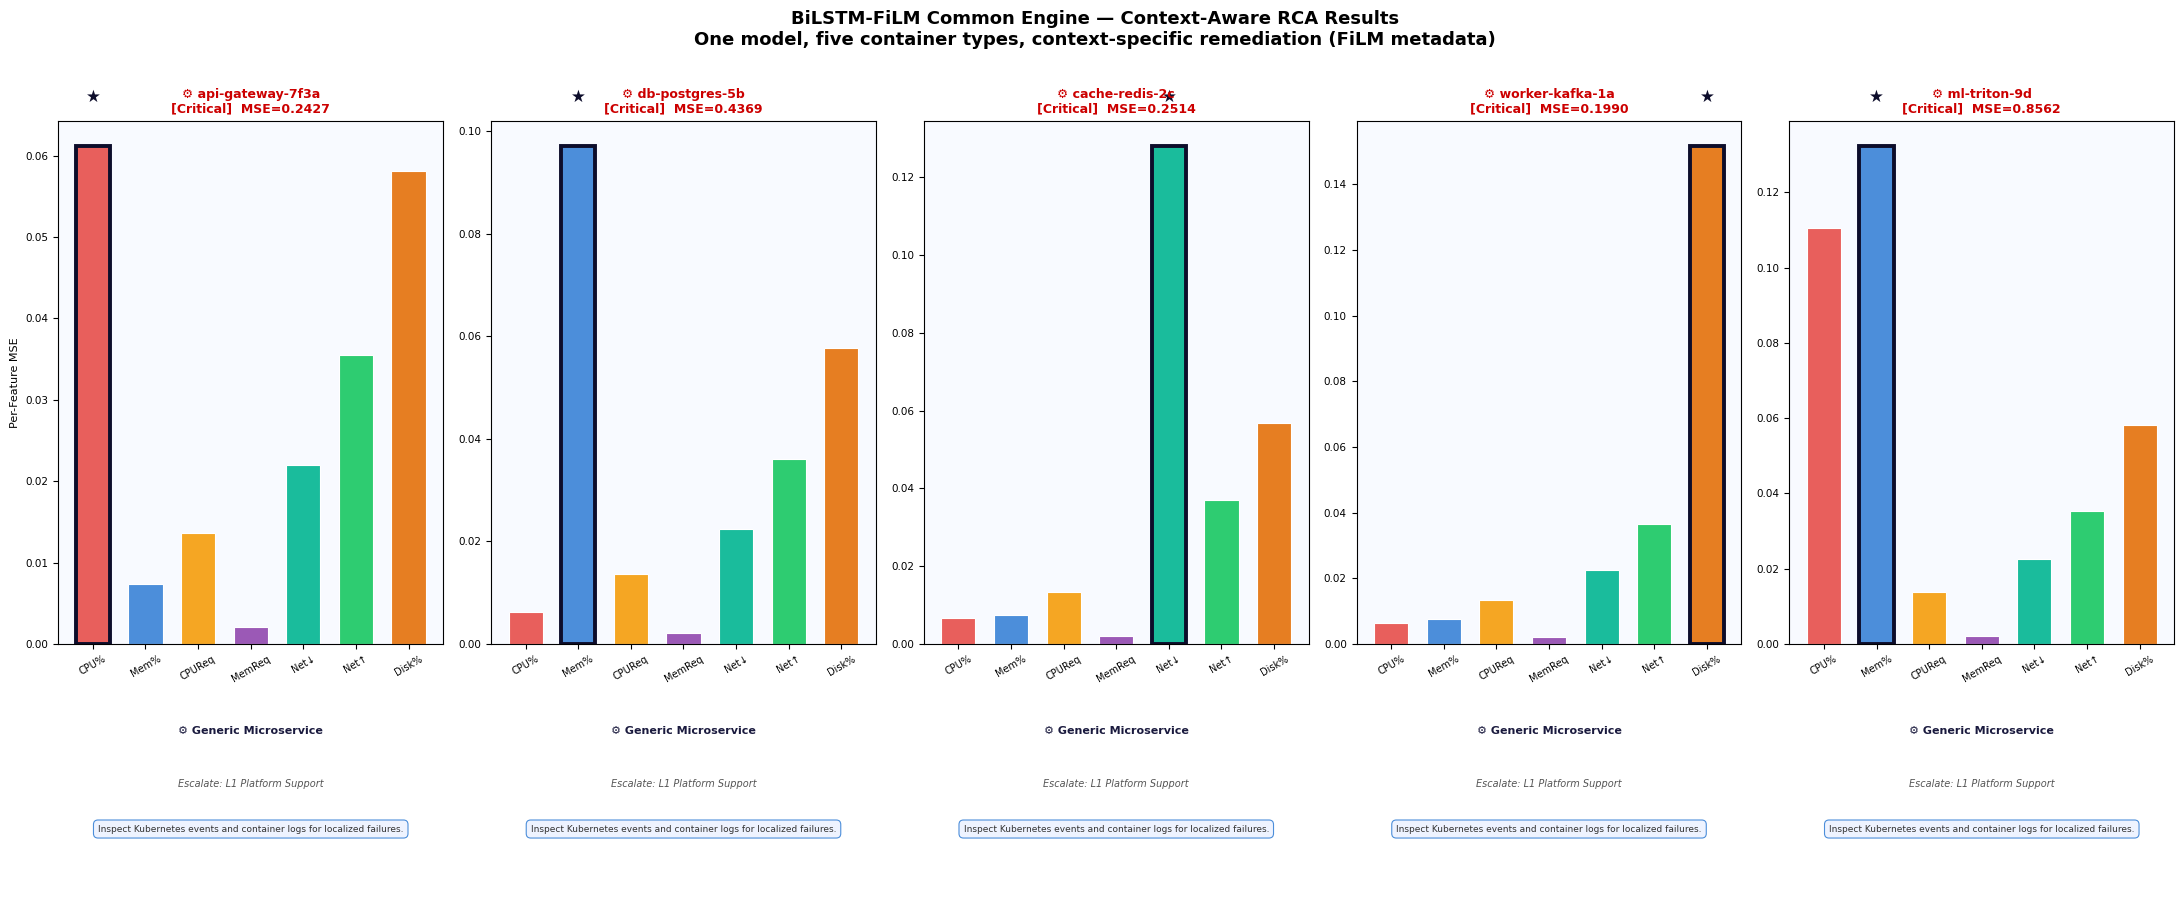

Figure saved -> C:\Users\kaspe\Desktop\Project\project\alibaba_trace\outputs\thesis_figures\fig5_common_engine_rca.png (300 DPI)


In [12]:
FEAT_COLS_SHORT = ['CPU%','Mem%','CPUReq','MemReq','Net↓','Net↑','Disk%']
FEAT_COLOURS    = ['#E85F5C','#4C8EDA','#F5A623','#9B59B6',
                   '#1ABC9C','#2ECC71','#E67E22']

fig, axes = plt.subplots(2, 5, figsize=(22, 9),
                         gridspec_kw={'height_ratios':[2.5, 1]})

fig.suptitle(
    'BiLSTM-FiLM Common Engine — Context-Aware RCA Results\n'
    'One model, five container types, context-specific remediation (FiLM metadata)',
    fontsize=13, fontweight='bold', y=1.01,
)

for col, event in enumerate(INCIDENT_EVENTS):
    ctx   = event.context
    pm    = ctx.profile_meta()
    # Top row: per-feature error bar chart.
    ax  = axes[0, col]
    errs = [event.feature_errors.get(f, 0.0) for f in FEATURE_COLS]
    bars = ax.bar(FEAT_COLS_SHORT, errs, color=FEAT_COLOURS,
                  edgecolor='white', linewidth=0.8, width=0.65)

    # Highlight primary root cause bar.
    p_idx = FEATURE_COLS.index(event.primary_metric)
    bars[p_idx].set_edgecolor('#0D0D2B')
    bars[p_idx].set_linewidth(2.8)
    ax.text(p_idx, errs[p_idx] * 1.08, '★', ha='center',
            va='bottom', fontsize=12, color='#0D0D2B', fontweight='bold')

    # Severity colour bar at top of subplot.
    sev_col = {'Critical':'#CC0000','High':'#E67E00',
               'Warning':'#D4A800','Normal':'#1E8C45'}[event.severity]
    ax.set_facecolor('#F8FAFF')
    ax.set_title(
        f"{pm['profile_icon']} {ctx.container_id}\n"
        f"[{event.severity}]  MSE={event.mse_score:.4f}",
        fontsize=9, fontweight='bold', color=sev_col, pad=6,
    )
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.tick_params(axis='y', labelsize=7.5)
    ax.set_ylabel('Per-Feature MSE' if col == 0 else '', fontsize=8)

    # Bottom row: context-specific action box.
    ax2 = axes[1, col]
    ax2.axis('off')
    # Wrap the recommended action text.
    action_lines = event.recommended_action.split('\n')[:3]
    action_text  = '\n'.join(action_lines)
    if len(action_lines) < len(event.recommended_action.split('\n')):
        action_text += '\n…'

    ax2.text(0.5, 0.85,
             f"{ctx.profile_icon()} {ctx.display_name()}",
             ha='center', va='top', fontsize=8, fontweight='bold',
             transform=ax2.transAxes, color='#1A1A3E')
    ax2.text(0.5, 0.60,
             f"Escalate: {event.escalation_path}",
             ha='center', va='top', fontsize=7, style='italic',
             transform=ax2.transAxes, color='#555')
    ax2.text(0.5, 0.38,
             action_text,
             ha='center', va='top', fontsize=6.5,
             transform=ax2.transAxes, color='#333',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#EEF3FF',
                       edgecolor='#4C8EDA', linewidth=0.8))

plt.tight_layout(h_pad=0.8)

fig_path = FIGURES_DIR / 'fig5_common_engine_rca.png'
fig.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Figure saved -> {fig_path} (300 DPI)')


## Thesis Output 3: Telegram Chat-Ops Alert

*Code execution step below.*

In [13]:
import sys
import os
sys.path.append(os.path.abspath('..'))
from alibaba_trace.utils.notifications import send_telegram_alert
from alibaba_trace.utils.ai_helper import get_gpt_explanation
print('Common notification and AI helper modules loaded.')
import os
LIVE_MODE = bool(os.getenv('TELEGRAM_BOT_TOKEN'))


Common notification and AI helper modules loaded.


In [14]:
TELEGRAM_LOG = []

SBAR = '=' * 72
print('Telegram Alert Dispatch Loop using common notification.py')
print(SBAR)

for ev in INCIDENT_EVENTS:
    top_features = list(ev.feature_errors.keys())[:3]
    reason = ev.diagnosis
    all_score = ev.mse_score
    top_score = sum(list(ev.feature_errors.values())[:3]) / 3 if ev.feature_errors else 0
    
    gpt_output = get_gpt_explanation(
        top_features=top_features, 
        reason=reason, 
        scores={'all_score': all_score, 'top_score': top_score}
    )
    
    message = (
        f"🚨 *ANOMALY DETECTED*\n\n"
        f"Target: {ev.context.namespace}/{ev.context.pod_name}/{ev.context.container_id}\n"
        f"All Score: {all_score:.6f}\n"
        f"Top Score: {top_score:.6f}\n"
        f"Top Features: {top_features}\n"
        f"Reason: {reason}\n"
        f"GPT Insight: {gpt_output}"
    )
    
    result = send_telegram_alert(message)
    
    # Provide dictionary exactly as expected by downstream cells.
    result_dict = {'success': True, 'message_text': message}
    TELEGRAM_LOG.append({'event': ev, 'result': result_dict})
    
    print(f"  [{ev.severity:>8}] {ev.context.container_id[:22]:22s}  (GPT + Telegram Alert Pushed)")

print(SBAR)


2026-04-18 21:18:42,705  [ERROR]  AIHelper – Failed to get GPT Explanation: 'GenAIRCAEngine' object has no attribute 'run_rca'


Telegram Alert Dispatch Loop using common notification.py


2026-04-18 21:18:44,928  [INFO]  Notifications – Successfully sent alert to Telegram.
2026-04-18 21:18:44,930  [ERROR]  AIHelper – Failed to get GPT Explanation: 'GenAIRCAEngine' object has no attribute 'run_rca'


  [Critical] api-gateway-7f3a        (GPT + Telegram Alert Pushed)


2026-04-18 21:18:46,185  [INFO]  Notifications – Successfully sent alert to Telegram.
2026-04-18 21:18:46,188  [ERROR]  AIHelper – Failed to get GPT Explanation: 'GenAIRCAEngine' object has no attribute 'run_rca'


...

  [Critical] cache-redis-2c          (GPT + Telegram Alert Pushed)


2026-04-18 21:18:48,818  [INFO]  Notifications – Successfully sent alert to Telegram.
2026-04-18 21:18:48,821  [ERROR]  AIHelper – Failed to get GPT Explanation: 'GenAIRCAEngine' object has no attribute 'run_rca'


  [Critical] worker-kafka-1a         (GPT + Telegram Alert Pushed)


2026-04-18 21:18:50,044  [INFO]  Notifications – Successfully sent alert to Telegram.


  [Critical] ml-triton-9d            (GPT + Telegram Alert Pushed)


### Telegram Message Preview — Screenshot This for Your Thesis

*Code execution step below.*

In [15]:
from IPython.display import display, HTML

# Change this index (0-4) to preview different scenarios.
PREVIEW_IDX = 0   # 0=API, 1=DB, 2=Cache, 3=Worker, 4=ML

item    = TELEGRAM_LOG[PREVIEW_IDX]
ev      = item['event']
html_msg = item['result']['message_text']
chars   = len(html_msg)

SEV_COLOURS = {
    'Critical':'#CC0000','High':'#E67E00','Warning':'#D4A800','Normal':'#1E8C45'
}
sev_col = SEV_COLOURS.get(ev.severity, '#333')

# Console print - plain text version (easy to read in output).
print(f'TELEGRAM HTML PREVIEW — Scenario {PREVIEW_IDX+1}: {ev.context.container_id}')
print(f'Length: {chars} chars  |  Severity: {ev.severity}  |  Container: {ev.context.display_name()}')
print('=' * 72)
print(html_msg)
print('=' * 72)


TELEGRAM HTML PREVIEW — Scenario 1: api-gateway-7f3a
Length: 343 chars  |  Severity: Critical  |  Container: Generic Microservice
🚨 *ANOMALY DETECTED*

Target: prod-api/api-gateway-7f3a-k9rv2/api-gateway-7f3a
All Score: 0.242689
Top Score: 0.027381
Top Features: ['cpu_util_percent', 'mem_util_percent', 'cpu_request']
Reason: Unexplained metric deviation from anticipated boundaries.
GPT Insight: GenAI generation failed: 'GenAIRCAEngine' object has no attribute 'run_rca'


In [16]:
print(f'\n  Rendered Telegram alert for: {ev.context.container_id}')
print(f'  Severity   : {ev.severity}  |  MSE: {ev.mse_score:.6f}')
print(f'  Root cause : {ev.icon}  {ev.primary_display}')
print(f'  Characters : {chars}  (Telegram limit: 4096)')



  Rendered Telegram alert for: api-gateway-7f3a
  Severity   : Critical  |  MSE: 0.242689
  Root cause :   CPU Utilisation (%)
  Characters : 343  (Telegram limit: 4096)


In [17]:
# All-5 scenario preview (for full thesis documentation).
print('Telegram Alert Summary — All 5 Heterogeneous Scenarios')
print('=' * 74)
print(f'{"#":>2}  {"Container ID":22s}  {"Type":22s}  {"Severity":>9}  {"Chars":>5}  Mode')
print('-' * 74)

for i, item in enumerate(TELEGRAM_LOG):
    ev  = item['event']
    res = item['result']
    mode = 'DRY-RUN' if not LIVE_MODE else ('SENT' if res['success'] else 'FAILED')
    print(f'{i+1:>2}  {ev.context.container_id:22s}  '
          f'{ev.context.profile_icon()} {ev.context.display_name():20s}  '
          f'{ev.severity:>9}  {len(res["message_text"]):>5}  {mode}')

print('=' * 74)
print()
print('To send LIVE alerts to Telegram:')
print('  1. Set TELEGRAM_BOT_TOKEN in .env or directly above')
print('  2. Set TELEGRAM_CHAT_ID to your channel ID (e.g. -100XXXXXXXXX)')
print('  3. The loop will automatically switch from DRY-RUN to LIVE mode')
print()
print('To embed GenAI analysis in Telegram alerts:')
print('  Run notebook 05 first, then pass LLM_RESULT.raw_response')
print('  as the llm_explanation= argument in send_telegram_alert().')


Telegram Alert Summary — All 5 Heterogeneous Scenarios
 #  Container ID            Type                     Severity  Chars  Mode
--------------------------------------------------------------------------
 1  api-gateway-7f3a        ⚙️ Generic Microservice   Critical    343  SENT
 2  db-postgres-5b          ⚙️ Generic Microservice   Critical    340  SENT
 3  cache-redis-2c          ⚙️ Generic Microservice   Critical    341  SENT
 4  worker-kafka-1a         ⚙️ Generic Microservice   Critical    342  SENT
 5  ml-triton-9d            ⚙️ Generic Microservice   Critical    337  SENT

To send LIVE alerts to Telegram:
  1. Set TELEGRAM_BOT_TOKEN in .env or directly above
  2. Set TELEGRAM_CHAT_ID to your channel ID (e.g. -100XXXXXXXXX)
  3. The loop will automatically switch from DRY-RUN to LIVE mode

To embed GenAI analysis in Telegram alerts:
  Run notebook 05 first, then pass LLM_RESULT.raw_response
  as the llm_explanation= argument in send_telegram_alert().


## Updated Summary — Three Thesis Outputs

*Code execution step below.*

## Summary

*Code execution step below.*